--- PUNTO 1.1: Patrón de colores (Rojo a Azul) ---


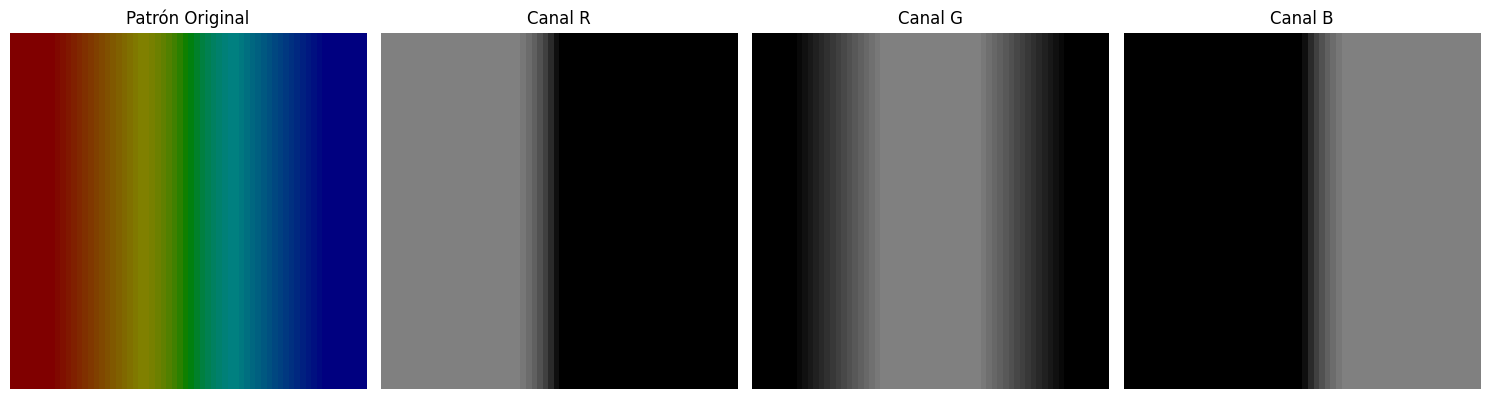

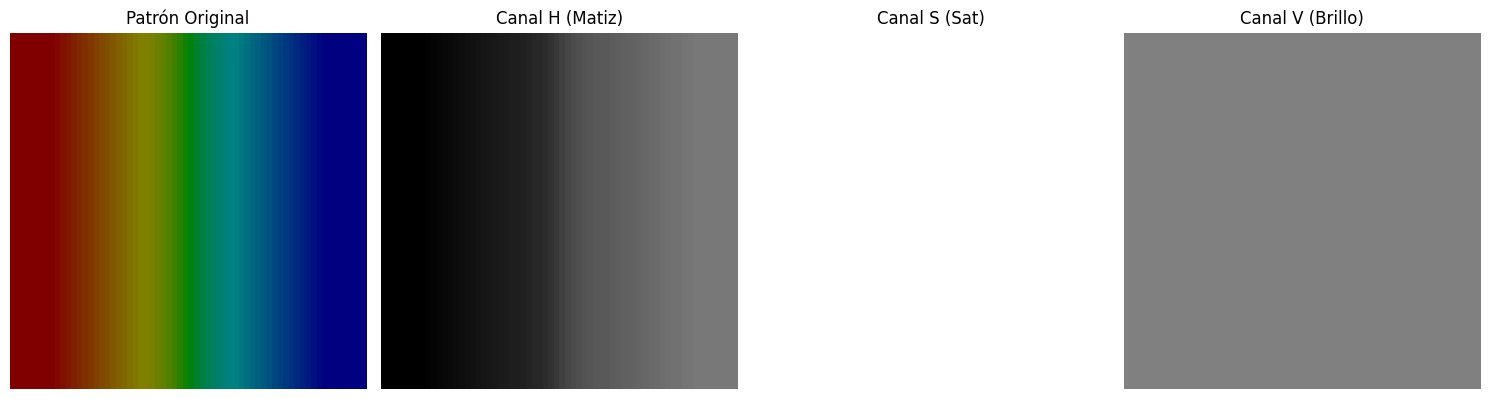

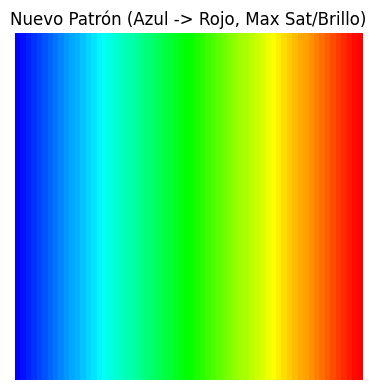


--- PUNTO 1.2: Colores Complementarios ---


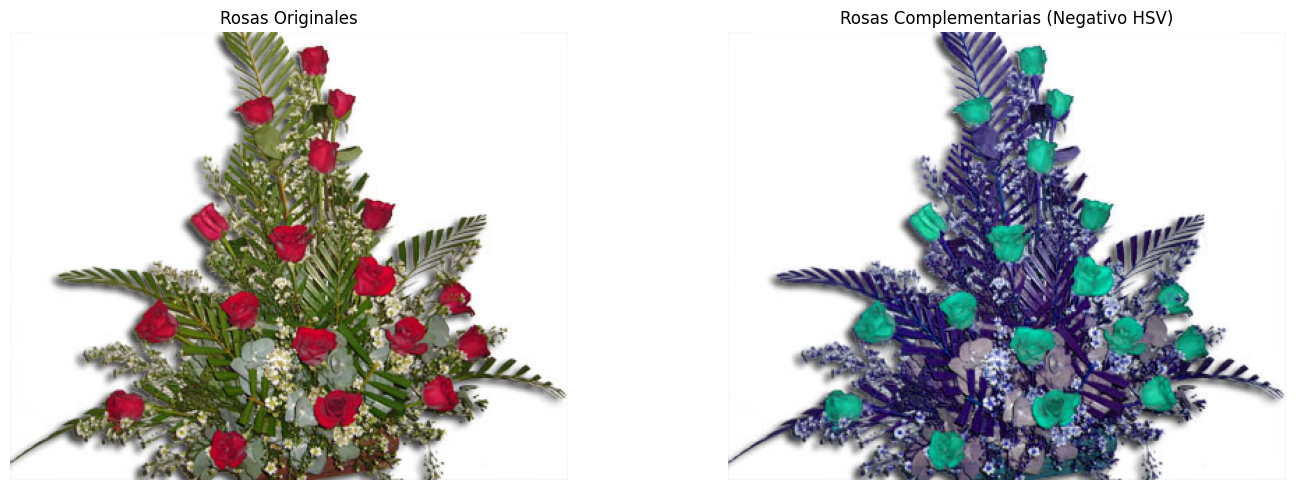

--- PUNTO 1.3: Perfiles de Intensidad (RGB vs HSV) ---


interactive(children=(IntSlider(value=50, description='fila'), Output()), _dom_classes=('widget-interact',))

<function __main__.trazar_perfiles_interactivo(fila)>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# ==========================================
# 1. FUNCIÓN DE VISUALIZACIÓN 
# ==========================================
def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    """Función para mostrar múltiples imágenes correctamente en RGB"""
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        # Convertir BGR a RGB si es una imagen a color (3 canales)
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray' if len(img.shape) == 2 else None, vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. RESOLUCIÓN DEL EJERCICIO 1
# ==========================================
def analizar_modelos_color():
    print("--- PUNTO 1.1: Patrón de colores (Rojo a Azul) ---")
    patron = cv2.imread('patron.tif')
    
    if patron is not None:
        # Extraer canales B, G, R
        B, G, R = cv2.split(patron)

        # Convertir a HSV y separar canales
        patron_hsv = cv2.cvtColor(patron, cv2.COLOR_BGR2HSV)
        H, S, V = cv2.split(patron_hsv)

        mostrar_imagenes([patron, R, G, B], ["Patrón Original", "Canal R", "Canal G", "Canal B"])
        mostrar_imagenes([patron, H, S, V], ["Patrón Original", "Canal H (Matiz)", "Canal S (Sat)", "Canal V (Brillo)"])

        # ------------------------------------------------------------------
        # Variación de azul a rojo, con S y V máximos (255)
        # ------------------------------------------------------------------
        alto, ancho = patron.shape[:2]
        
        # En OpenCV: Rojo = 0, Azul = 120. 
        # Creamos un degradado 1D que vaya de 120 a 0 a lo largo del ancho de la imagen.
        gradiente_1d = np.linspace(120, 0, ancho, dtype=np.uint8)
        
        # Repetimos esa fila de colores para que cubra todo el alto de la imagen
        H_nuevo = np.tile(gradiente_1d, (alto, 1))
        
        # Saturación y Brillo al máximo (255) en toda la matriz
        S_nuevo = np.full((alto, ancho), 255, dtype=np.uint8)
        V_nuevo = np.full((alto, ancho), 255, dtype=np.uint8)
        
        # Unimos y volvemos a BGR para poder graficar
        patron_nuevo_hsv = cv2.merge([H_nuevo, S_nuevo, V_nuevo])
        patron_nuevo_rgb = cv2.cvtColor(patron_nuevo_hsv, cv2.COLOR_HSV2BGR)
        
        mostrar_imagenes([patron_nuevo_rgb], ["Nuevo Patrón (Azul -> Rojo, Max Sat/Brillo)"], figsize=(8, 4))
    else:
        print("⚠️ Falta cargar 'patron.tif'")


    print("\n--- PUNTO 1.2: Colores Complementarios ---")
    rosas = cv2.imread('rosas.jpg')
    
    if rosas is not None:
        rosas_hsv = cv2.cvtColor(rosas, cv2.COLOR_BGR2HSV)
        H_r, S_r, V_r = cv2.split(rosas_hsv)

        # ------------------------------------------------------------------
        # Generar la imagen complementaria.
        # ------------------------------------------------------------------
        # El complementario está a 180° en la rueda cromática (90 en la escala de 0-179 de OpenCV).
        # Pasamos a int16 temporalmente para sumar sin que el límite de 255 nos rompa el cálculo,
        # aplicamos módulo 180 para dar la vuelta a la rueda, y volvemos a uint8.
        H_comp = ((H_r.astype(np.int16) + 90) % 180).astype(np.uint8)
        
        # Unimos el nuevo matiz conservando la textura/iluminación original (S y V)
        rosas_comp_hsv = cv2.merge([H_comp, S_r, V_r])
        rosas_comp = cv2.cvtColor(rosas_comp_hsv, cv2.COLOR_HSV2BGR)

        mostrar_imagenes([rosas, rosas_comp], ["Rosas Originales", "Rosas Complementarias (Negativo HSV)"])
    else:
        print("⚠️ Falta cargar 'rosas.jpg'")
    

# Ejecutar el ejercicio
analizar_modelos_color()
print("--- PUNTO 1.3: Perfiles de Intensidad (RGB vs HSV) ---")

def trazar_perfiles_interactivo(fila):
    img = cv2.imread('patron.tif')
    if img is None:
        print("⚠️ Falta cargar 'patron.tif'")
        return

    # Convertir a RGB (para plotear y extraer canales) y a HSV
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Extraer canales
    R, G, B = cv2.split(img_rgb)
    H, S, V = cv2.split(img_hsv)

    # Extraer los perfiles de la fila seleccionada
    perfil_R = R[fila, :]
    perfil_G = G[fila, :]
    perfil_B = B[fila, :]

    perfil_H = H[fila, :]
    perfil_S = S[fila, :]
    perfil_V = V[fila, :]

    # Crear la figura con 2 subplots (uno arriba del otro)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # Gráfico 1: Perfiles RGB
    ax1.plot(perfil_R, color='red', label='Canal R (Rojo)')
    ax1.plot(perfil_G, color='green', label='Canal G (Verde)')
    ax1.plot(perfil_B, color='blue', label='Canal B (Azul)')
    ax1.set_title(f'Perfiles RGB - Fila {fila}')
    ax1.set_ylabel('Intensidad (0-255)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Perfiles HSV
    # En OpenCV H va de 0-179, S y V de 0-255.
    ax2.plot(perfil_H, color='purple', label='Canal H (Matiz, 0-179)')
    ax2.plot(perfil_S, color='orange', label='Canal S (Saturación)')
    ax2.plot(perfil_V, color='black', label='Canal V (Brillo)')
    ax2.set_title(f'Perfiles HSV - Fila {fila}')
    ax2.set_xlabel('Columna (X)')
    ax2.set_ylabel('Valor')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Asumiendo que patron.tif tiene un alto razonable, seteamos el slider de 0 a 100
# Si la imagen es más grande, puedes ajustar el 'max' del slider
interact(trazar_perfiles_interactivo, fila=IntSlider(min=0, max=100, step=1, value=50))

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntRangeSlider

def mostrar_pseudocolor(rango):
    # Cargar la imagen en escala de grises
    img_rio = cv2.imread('rio.jpg', cv2.IMREAD_GRAYSCALE)
    
    if img_rio is None:
        print("❌ Error: No se encuentra 'rio.jpg'.")
        return

    # 1. Crear una base en color (copia de la intensidad en los 3 canales)
    # Esto permite que el resto de la imagen se vea "normal" en gris
    rio_pseudocolor = cv2.cvtColor(img_rio, cv2.COLOR_GRAY2BGR)

    # 2. Definir el rango de interés (Agua) extraído del slider
    bajo, alto = rango
    
    # 3. Generar la máscara binaria para ese rango de intensidades
    mascara_agua = cv2.inRange(img_rio, bajo, alto)

    # 4. Asignar el color AMARILLO (0, 255, 255 en BGR) a los píxeles de la máscara
    rio_pseudocolor[mascara_agua > 0] = [0, 255, 255]

    # Visualización
    plt.figure(figsize=(15, 7))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_rio, cmap='gray')
    plt.title('Imagen Original (Grises)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # Convertimos BGR a RGB solo para mostrar con Matplotlib
    plt.imshow(cv2.cvtColor(rio_pseudocolor, cv2.COLOR_BGR2RGB))
    plt.title(f'Pseudocolor Detectado (Rango: {bajo}-{alto})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva: ajustá el rango para cubrir solo el agua del río
interact(mostrar_pseudocolor, 
         rango=IntRangeSlider(value=[20, 60], min=0, max=255, step=1, 
                              description='Rango Grises:', continuous_update=False))

interactive(children=(IntRangeSlider(value=(20, 60), continuous_update=False, description='Rango Grises:', max…

<function __main__.mostrar_pseudocolor(rango)>

--- EJERCICIO 3.1: Manejo de Histograma (Ecualización) ---


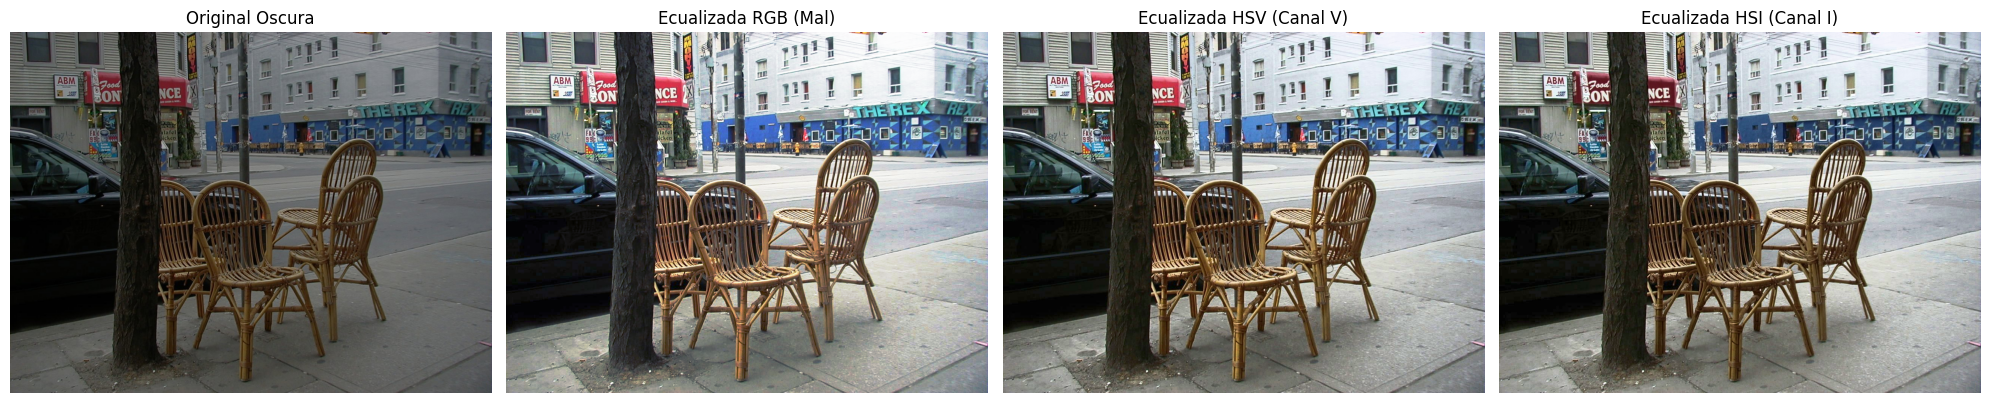


--- EJERCICIO 3.2: Realce mediante Acentuado (Filtro Pasa Altos) ---


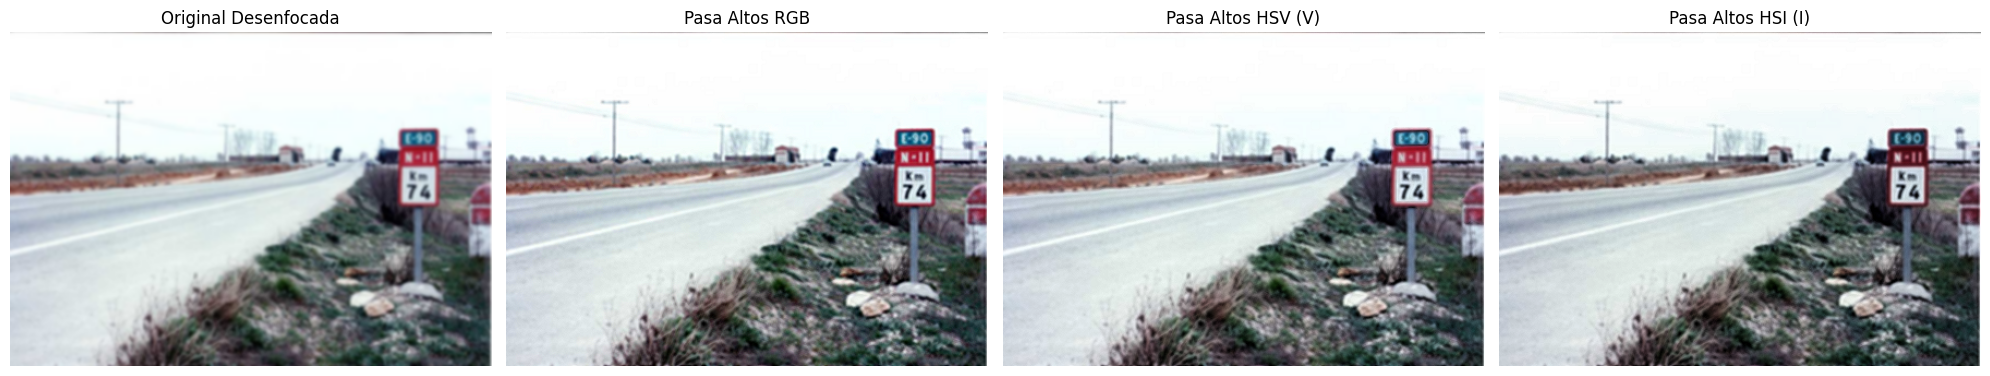

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray' if len(img.shape) == 2 else None, vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

def calcular_canal_I_hsi(img_bgr):
    """Calcula el canal I del modelo HSI: I = (B+G+R)/3"""
    b, g, r = cv2.split(img_bgr.astype(np.float32))
    I = (b + g + r) / 3.0
    return I.astype(np.uint8)

def reconstruir_hsi(H, S, I_modificada):
    """Reconstruye una imagen BGR a partir de H, S (de HSV) y una I (de HSI) modificada."""
    # Para simplificar en este ejercicio y visualizar el efecto, 
    # usamos el algoritmo de OpenCV para volver desde HSV, inyectando la I modificada en lugar de V.
    # Matemáticamente HSI a RGB es más complejo, pero esta aproximación sirve para ver el contraste.
    hsi_fusion = cv2.merge([H, S, I_modificada])
    return cv2.cvtColor(hsi_fusion, cv2.COLOR_HSV2BGR)

print("--- EJERCICIO 3.1: Manejo de Histograma (Ecualización) ---")
img_oscura = cv2.imread('chairs_oscura.jpg')

if img_oscura is not None:
    # a) Ecualización en RGB (Plano por plano)
    b, g, r = cv2.split(img_oscura)
    b_eq = cv2.equalizeHist(b)
    g_eq = cv2.equalizeHist(g)
    r_eq = cv2.equalizeHist(r)
    img_eq_rgb = cv2.merge([b_eq, g_eq, r_eq])

    # b) Ecualización en HSV (Solo canal V)
    img_hsv = cv2.cvtColor(img_oscura, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)
    v_eq = cv2.equalizeHist(v)
    img_eq_hsv = cv2.cvtColor(cv2.merge([h, s, v_eq]), cv2.COLOR_HSV2BGR)

    # c) Ecualización en HSI (Solo canal I)
    I = calcular_canal_I_hsi(img_oscura)
    I_eq = cv2.equalizeHist(I)
    img_eq_hsi = reconstruir_hsi(h, s, I_eq)

    # Visualizamos los resultados
    mostrar_imagenes([img_oscura, img_eq_rgb, img_eq_hsv, img_eq_hsi], 
                     ["Original Oscura", "Ecualizada RGB (Mal)", "Ecualizada HSV (Canal V)", "Ecualizada HSI (Canal I)"], 
                     figsize=(20, 5))
else:
    print("⚠️ Falta cargar 'chairs_oscura.jpg'")

print("\n--- EJERCICIO 3.2: Realce mediante Acentuado (Filtro Pasa Altos) ---")
img_desenfocada = cv2.imread('camino.tif')

if img_desenfocada is not None:
    # Máscara pasa altos de suma 1 (Realce de bordes preservando luminosidad)
    kernel_pasa_altos = np.array([[ 0, -1,  0],
                                  [-1,  5, -1],
                                  [ 0, -1,  0]], dtype=np.float32)

    # a) Filtrado en RGB (Plano por plano)
    # Se aplica directamente a la imagen a color. cv2.filter2D lo hace por cada canal automáticamente.
    img_pa_rgb = cv2.filter2D(img_desenfocada, -1, kernel_pasa_altos)

    # b) Filtrado en HSV (Solo canal V)
    img_camino_hsv = cv2.cvtColor(img_desenfocada, cv2.COLOR_BGR2HSV)
    h_c, s_c, v_c = cv2.split(img_camino_hsv)
    v_pa = cv2.filter2D(v_c, -1, kernel_pasa_altos)
    img_pa_hsv = cv2.cvtColor(cv2.merge([h_c, s_c, v_pa]), cv2.COLOR_HSV2BGR)

    # c) Filtrado en HSI (Solo canal I)
    I_c = calcular_canal_I_hsi(img_desenfocada)
    I_pa = cv2.filter2D(I_c, -1, kernel_pasa_altos)
    img_pa_hsi = reconstruir_hsi(h_c, s_c, I_pa)

    mostrar_imagenes([img_desenfocada, img_pa_rgb, img_pa_hsv, img_pa_hsi], 
                     ["Original Desenfocada", "Pasa Altos RGB", "Pasa Altos HSV (V)", "Pasa Altos HSI (I)"], 
                     figsize=(20, 5))
else:
    print("⚠️ Falta cargar 'camino.tif'")

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntRangeSlider, IntSlider, Checkbox

def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray' if len(img.shape) == 2 else None, vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

def comparar_segmentacion(img_path, r_c, g_c, b_c, radio_rgb, h_rango, s_rango):
    # Cargar imagen
    img = cv2.imread(img_path)
    if img is None: 
        print(f"⚠️ No se encontró la imagen: {img_path}")
        return

    # ====================================================
    # MÉTODO 1: RGB (Distancia Euclidiana - Esfera 3D)
    # ====================================================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convertimos a float32 para evitar desbordamientos al restar
    img_float = img_rgb.astype(np.float32)
    centro_rgb = np.array([r_c, g_c, b_c], dtype=np.float32)
    
    # Calculamos la distancia euclidiana de cada píxel al centro de la esfera
    # dist = sqrt((R-Rc)^2 + (G-Gc)^2 + (B-Bc)^2)
    distancias = np.linalg.norm(img_float - centro_rgb, axis=2)
    
    # Umbralizamos: Si la distancia es menor al radio, pertenece a la máscara (255)
    mascara_rgb = np.where(distancias <= radio_rgb, 255, 0).astype(np.uint8)
    seg_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_rgb)

    # ====================================================
    # MÉTODO 2: HSV (Subespacio Rectangular - inRange)
    # ====================================================
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Definimos límites (Ignoramos V, dejándolo de 0 a 255 para absorber la iluminación)
    lower_hsv = np.array([h_rango[0], s_rango[0], 0])
    upper_hsv = np.array([h_rango[1], s_rango[1], 255])
    
    mascara_hsv = cv2.inRange(img_hsv, lower_hsv, upper_hsv)
    
    # Usamos img_rgb para que Matplotlib lo muestre con colores correctos
    seg_hsv = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara_hsv)

    # ====================================================
    # VISUALIZACIÓN COMPARATIVA
    # ====================================================
    mostrar_imagenes(
        [img_rgb, mascara_rgb, mascara_hsv], 
        ["Imagen Original", f"Máscara RGB (Esfera R={radio_rgb})", f"Máscara HSV (Rango H:{h_rango})"]
    )
    mostrar_imagenes(
        [img_rgb, seg_rgb, seg_hsv], 
        ["Imagen Original", "Segmentación RGB", "Segmentación HSV"]
    )

print("--- EJERCICIO 4: Segmentación RGB vs HSV ---")
# Puedes cambiar 'futbol.jpg' por las imágenes de rostros (ej: 's01_i08_H_CM.png')
interact(comparar_segmentacion,
         img_path=['futbol.jpg', 's01_i08_H_CM.png', 's03_i10_H_DM.png'],
         # Parámetros RGB (Centro de la esfera y radio)
         r_c=IntSlider(min=0, max=255, value=180, description='R Centro'),
         g_c=IntSlider(min=0, max=255, value=130, description='G Centro'),
         b_c=IntSlider(min=0, max=255, value=100, description='B Centro'),
         radio_rgb=IntSlider(min=10, max=150, value=60, description='Radio Esfera'),
         # Parámetros HSV (Rangos de Matiz y Saturación)
         h_rango=IntRangeSlider(min=0, max=179, value=[0, 25], description='Matiz (H)'),
         s_rango=IntRangeSlider(min=0, max=255, value=[50, 150], description='Saturación (S)')
)

--- EJERCICIO 4: Segmentación RGB vs HSV ---


interactive(children=(Dropdown(description='img_path', options=('futbol.jpg', 's01_i08_H_CM.png', 's03_i10_H_D…

<function __main__.comparar_segmentacion(img_path, r_c, g_c, b_c, radio_rgb, h_rango, s_rango)>